# Housing Affordability in Regions Surrounding UC Campuses

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [X] NO - keep private

## Link to video
https://youtu.be/J00hgHgsb2Q
## Overview

We investigated how housing prices and affordability changed from 2020 to 2024 in regions surrounding University of California (UC) campuses, operationalized as eight UC-adjacent counties: Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo. Using Zillow Home Value Index (ZHVI) data for single-family homes and American Community Survey (ACS) median household income at the county level, we computed price-to-income ratios and examined the relationship between county income and home values across all California counties. We found that affordability varies widely across UC-adjacent counties: Santa Barbara and Los Angeles show the highest price-to-income ratios (about 14.5 and 13.2), while Merced and Riverside show the lowest (about 6.3 and 6.6). At the county level, median household income and average home value are strongly positively correlated (Pearson r ≈ 0.91), indicating that higher-income counties also tend to have higher housing prices. Overall, our descriptive results suggest that housing near many UC campuses is expensive relative to local income and that coastal and metropolitan UC regions are less affordable than inland ones.

## Authors

- Andrew Zhang: Find dataset 2
- Andy Cao: Data wrangling for Dataset 1, Writing – original draft, EDA Editing
- Vicky Huang: Hypothesis; background; found and described Dataset 1; EDA editing， video
- Jasmine Lou: Data wrangling for Dataset 2, Writing – original draft, video
- Yiwen Huang: Update info, Writing – review and editing

# Research Question

How has housing affordability changed from 2020 to 2024 in UC-adjacent counties, and how do these changes relate to local income levels?

Specifically, we examine whether average home values in UC-adjacent counties increased faster than median household income and whether affordability differs between coastal/metropolitan counties and inland counties. Our main variables are average home value, median household income, and affordability measured by the price-to-income ratio. The analysis is primarily descriptive and comparative. We visualize housing value and income patterns, compare affordability across counties, and examine changes over time using public data from Zillow and the U.S. Census ACS.


## Background and Prior Work

Housing affordability has become a major social and economic issue in California, especially in areas with strong demand and limited housing supply. Regions surrounding University of California campuses may face additional pressure because of student demand, faculty and staff housing needs, and broader regional growth. Prior work and public discussion suggest that California housing prices, especially in coastal and metropolitan areas, have increased rapidly, while income growth has been slower and less even across regions.

This project examines whether those broader affordability patterns also appear in UC-adjacent counties. Using Zillow Home Value Index (ZHVI) data and American Community Survey (ACS) median household income data, we compare housing values, income, and affordability across counties associated with UC campuses. Our goal is not to identify a single causal explanation, but to describe affordability patterns and how they changed over time from 2020 to 2024.

# Hypothesis


We hypothesize that from 2020 to 2024, average home values in UC-adjacent counties increased faster than median household income, causing housing affordability to worsen over time. We also hypothesize that coastal and major metropolitan UC-adjacent counties, such as Alameda, Los Angeles, Orange, San Diego, and Santa Barbara, will have higher home values and higher price-to-income ratios than more inland counties such as Riverside, Merced, and Yolo.

## Data

### Data overview

**Dataset 1: Zillow Home Value Index (ZHVI), Single-Family Residences**
- **Dataset name:** Zillow Home Value Index (ZHVI), Single-Family Residences, ZIP code level.
- **Source / link:** Zillow Research Data.
- **Observations:** One row per ZIP code. We filter the dataset to California ZIP codes and then aggregate ZIP-level home values to the county level.
- **Variables:** `RegionID`, `RegionName` (ZIP code), `State`, `Metro`, `CountyName`, and monthly home value columns in U.S. dollars.
- **Relevance:** This dataset provides a consistent measure of housing values over time at a relatively fine geographic level. We aggregate these values to the county level so they can be compared across UC-adjacent counties.
- **Limitations:** ZHVI is an estimate rather than an exact transaction price, the data are originally at the ZIP-code level and must be aggregated, and the dataset reflects single-family homes only.

**Dataset 2: California County Income**
- **Source:** U.S. Census American Community Survey (ACS) table B19013, processed into `income_acs_ca_2020_2024.csv`.
- **Observations:** One row per county per year.
- **Key variables:** `county`, `year`, `median_household_income`.
- **Relevance:** County-level income allows us to compare local earnings with housing values and measure affordability.
- **Limitations:** ACS estimates are survey-based and include sampling error.

**How we use them together.** We filter Zillow data to California, aggregate ZIP-level home values to the county level, and merge these county-level housing values with county-level ACS median household income. Because the two datasets merge most reliably at the county level, we operationalize “regions surrounding UC campuses” as eight UC-adjacent counties: Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo. This allows us to compare affordability across counties and examine how home values, income, and price-to-income ratios changed from 2020 to 2024.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!!
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries;
# each dict has keys of
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  5.74it/s]   

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  5.53it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 — Zillow Home Value Index (ZHVI), Single-Family by ZIP

We use the Zillow Home Value Index (ZHVI) dataset for single-family residences at the ZIP-code level. Each row corresponds to a ZIP code and contains typical home values in U.S. dollars across many months and years. This dataset serves as the main housing-price input for our exploratory and comparative analysis.

To prepare the dataset, we:
- filter to California ZIP codes (`State == 'CA'`)
- keep key geographic columns (`RegionID`, `RegionName`, `State`, `CountyName`, `Metro`) along with the monthly home-value columns
- drop rows where all relevant date columns are missing or zero
- standardize county names so they can be merged with county-level income data

The cleaned California subset is saved as `data/02-processed/zhvi_sfr_zip_ca.csv`. If only the older mirror is available, the processed fallback file is `data/02-processed/zhvi_sfr_zip_ca_2018.csv`. For the main 2020–2024 analysis, we use the processed ZHVI file that contains monthly columns for 2020 through 2024.

After loading the cleaned file, we create a standardized `county` field from `CountyName`, identify the monthly columns for 2020–2024, and then aggregate ZIP-level home values to the county level. This allows us to compare housing affordability across the eight UC-adjacent counties used in the project: Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo.

**Limitations:** ZHVI is an estimated housing-value measure rather than an exact transaction price, it reflects single-family homes only, and the data must be aggregated from ZIP codes to counties before merging with the income dataset.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

zhvi_path = "data/02-processed/zhvi_sfr_zip_ca.csv"
if not os.path.exists(zhvi_path):
    zhvi_path = "data/02-processed/zhvi_sfr_zip_ca_2018.csv"


zhvi_ca = pd.read_csv(zhvi_path)

# Clean county names
if "CountyName" in zhvi_ca.columns:
    zhvi_ca["county"] = zhvi_ca["CountyName"].str.replace(" County", "", regex=False)
else:
    raise ValueError("CountyName column not found in ZHVI dataset.")

# UC-adjacent counties used in project
uc_counties = [
    "Alameda", "Los Angeles", "Orange", "San Diego",
    "Santa Barbara", "Riverside", "Merced", "Yolo"
]

coastal_metro = ["Alameda", "Los Angeles", "Orange", "San Diego", "Santa Barbara"]
inland = ["Riverside", "Merced", "Yolo"]

# Find monthly date columns from 2020–2024 if present
target_years = ["2020", "2021", "2022", "2023", "2024"]
date_cols = [c for c in zhvi_ca.columns if any(str(c).startswith(y + "-") for y in target_years)]

print("ZHVI shape:", zhvi_ca.shape)
print("Number of 2020–2024 monthly columns in ZHVI:", len(date_cols))

ZHVI shape: (1528, 323)
Number of 2020–2024 monthly columns in ZHVI: 60


### Dataset #2 — California County Income

We use county-level median household income data from the U.S. Census American Community Survey (ACS), table B19013, for California counties from 2020 to 2024. This dataset provides the income measure used to compare local earnings with housing values and to calculate affordability.

To prepare the dataset, we combine the ACS county income files for 2020–2024 and save the processed result as `data/02-processed/income_acs_ca_2020_2024.csv`. The file includes one row per county per year, with the main variables `county`, `year`, and `median_household_income`.

In the analysis, we load `income_acs_ca_2020_2024.csv` and aggregate the data to one row per county by taking the mean median household income over 2020–2024. This allows the income data to align with our 2020–2024 average county home values from the Zillow dataset.

**Limitations:** ACS income values are survey-based estimates rather than exact measurements, so they include sampling error. In addition, county-level averages do not capture within-county differences in income.

In [4]:
import pandas as pd

income_path = "data/02-processed/income_acs_ca_2020_2024.csv"
income_raw = pd.read_csv(income_path)
income = income_raw.groupby("county")["median_household_income"].mean().reset_index()

print("Income dataset shape:", income.shape)
print("Columns:", list(income.columns))
print("\nPreview:")
print(income.head())

print("\nSummary of median_household_income (USD):")
print(income["median_household_income"].describe())

Income dataset shape: (58, 2)
Columns: ['county', 'median_household_income']

Preview:
      county  median_household_income
0    Alameda                 119000.0
1     Alpine                  99835.4
2     Amador                  75913.0
3      Butte                  63484.4
4  Calaveras                  74644.6

Summary of median_household_income (USD):
count        58.000000
mean      81272.493103
std       24130.618507
min       47560.600000
25%       62856.550000
50%       75278.800000
75%       96493.650000
max      149779.000000
Name: median_household_income, dtype: float64


## Results

### Exploratory Data Analysis

In this section, we explore how housing values and affordability vary across California counties, with a focus on UC-adjacent counties. We load the fully processed datasets from `data/02-processed`:

- `zhvi_sfr_zip_ca.csv`: cleaned Zillow Home Value Index (ZHVI) data for California ZIP codes, used to measure home values
- `income_acs_ca_2020_2024.csv`: county-level ACS median household income data for 2020–2024

Our exploratory analysis has two main goals. First, we summarize the distribution of home values and income across UC-adjacent counties and compute a simple affordability measure using the price-to-income ratio. Second, we examine the broader relationship between county-level income and home values across California using visualizations and correlation analysis. Throughout this section, we interleave code, figures, and written interpretation. Reusable processing steps, such as loading processed data and aggregating ZIP-level values to the county level, build on the data-wrangling work completed in earlier checkpoints.

### Section 1 — Affordability Across UC-Adjacent Counties

In this section, we construct a cross-sectional view of housing affordability in eight UC-adjacent counties: Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo. Using the cleaned ZHVI dataset, we aggregate ZIP-level home values to the county level and merge them with county-level ACS median household income averaged over 2020–2024.

From the merged data, we compute and visualize the price-to-income ratio, defined as average home value divided by median household income, for each UC-adjacent county. This provides a simple measure of affordability: higher ratios indicate that home values are large relative to local income. We then compare which UC-adjacent counties appear most and least affordable and connect these patterns back to our research question about housing pressure near UC campuses.

Merged UC-adjacent counties:
       county   home_value  median_household_income  price_to_income
Santa Barbara 1.307557e+06                  89950.2        14.536457
  Los Angeles 1.083556e+06                  81801.6        13.246149
       Orange 1.238239e+06                 106855.6        11.587966
    San Diego 9.739509e+05                  95238.6        10.226430
      Alameda 1.150364e+06                 119000.0         9.666926
         Yolo 5.685005e+05                  83559.8         6.803516
    Riverside 5.496092e+05                  82809.8         6.637007
       Merced 3.894184e+05                  62103.4         6.270485


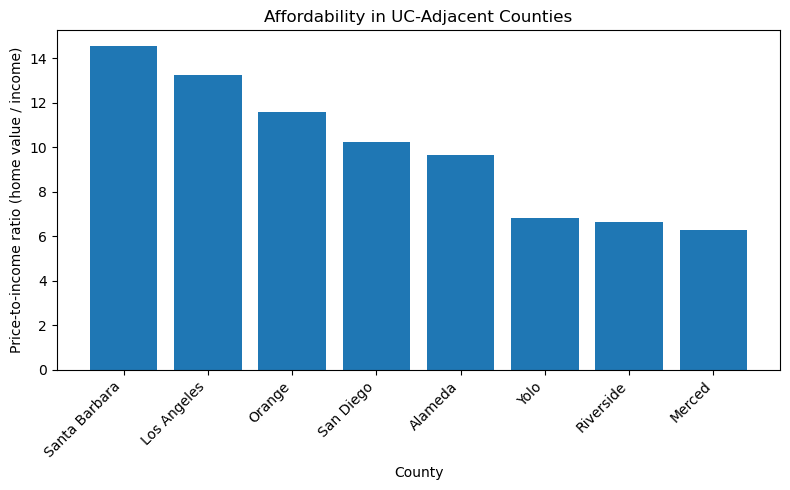

In [5]:
zhvi_ca["home_value_2020_2024"] = zhvi_ca[date_cols].mean(axis=1)

county_home = (
    zhvi_ca.groupby("county", as_index=False)["home_value_2020_2024"]
    .mean()
    .rename(columns={"home_value_2020_2024": "home_value"})
)

income_avg = (
    income_raw.groupby("county", as_index=False)["median_household_income"]
    .mean()
)

merged_all = county_home.merge(income_avg, on="county", how="inner")
merged_all["price_to_income"] = merged_all["home_value"] / merged_all["median_household_income"]
merged_uc = merged_all[merged_all["county"].isin(uc_counties)].copy()
merged_uc = merged_uc.sort_values("price_to_income", ascending=False)

print("Merged UC-adjacent counties:")
print(
    merged_uc[["county", "home_value", "median_household_income", "price_to_income"]]
    .to_string(index=False)
)

plt.figure(figsize=(8, 5))
plt.bar(merged_uc["county"], merged_uc["price_to_income"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Price-to-income ratio (home value / income)")
plt.xlabel("County")
plt.title("Affordability in UC-Adjacent Counties")
plt.tight_layout()
plt.show()

### Coastal/Metropolitan vs Inland Comparison

To make the regional pattern easier to interpret, we group the UC-adjacent counties into two categories: coastal/metropolitan and inland. This allows us to compare average affordability between the two groups more directly.


           group  mean_home_value   mean_income  mean_price_to_income
0  Coastal/Metro     1.150734e+06  98569.200000             11.852786
1         Inland     5.025094e+05  76157.666667              6.570336


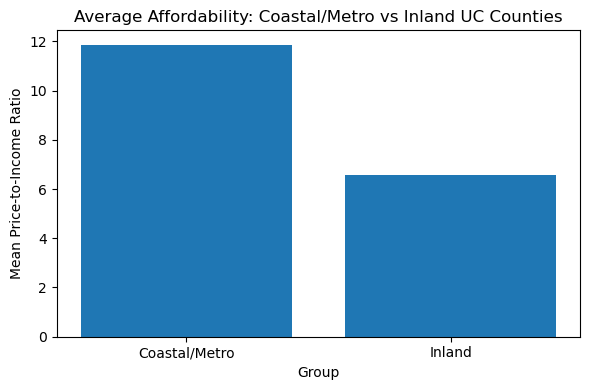

In [6]:
group_map = {c: "Coastal/Metro" for c in coastal_metro}
group_map.update({c: "Inland" for c in inland})

group_df = merged_uc.copy()
group_df["group"] = group_df["county"].map(group_map)

group_summary = (
    group_df.groupby("group")
    .agg(mean_home_value=("home_value", "mean"),
         mean_income=("median_household_income", "mean"),
         mean_price_to_income=("price_to_income", "mean"))
    .reset_index()
)

print(group_summary)

plt.figure(figsize=(6, 4))
plt.bar(group_summary["group"], group_summary["mean_price_to_income"])
plt.xlabel("Group")
plt.ylabel("Mean Price-to-Income Ratio")
plt.title("Average Affordability: Coastal/Metro vs Inland UC Counties")
plt.tight_layout()
plt.show()

#### Interpretation

This comparison shows that the coastal/metropolitan group has a much higher average price-to-income ratio than the inland group (about 11.85 vs. 6.57). This means housing is generally less affordable in coastal and metropolitan UC-adjacent counties. The grouped result reinforces the county-level pattern and provides additional support for our second hypothesis that coastal and metro UC regions are less affordable than inland regions.

### Section 2 — County-Level Relationship Between Income and Home Values

In this section, we examine the relationship between county median household income and county average home value across California. We combine county-level ACS median household income (2020–2024 average) with county-level Zillow home values, created by aggregating ZIP-level home values to the county level. We then visualize the relationship with a scatter plot and compute the Pearson correlation coefficient to measure the strength of the association.

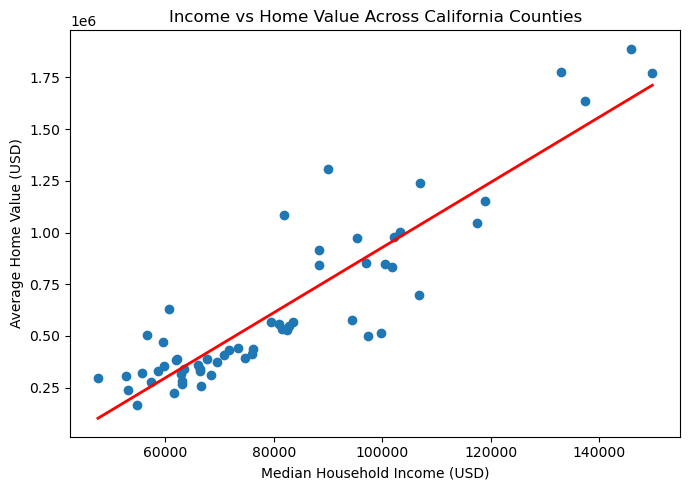

Pearson r: 0.9065827049244547
R-squared: 0.8218922008681409
p-value: 1.2190283479010412e-22


In [7]:
x = merged_all["median_household_income"].values
y = merged_all["home_value"].values

r, p_value = stats.pearsonr(x, y)
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(7, 5))
plt.scatter(merged_all["median_household_income"], merged_all["home_value"])
plt.plot(x_line, y_line, color="red", linewidth=2)
plt.xlabel("Median Household Income (USD)")
plt.ylabel("Average Home Value (USD)")
plt.title("Income vs Home Value Across California Counties")
plt.tight_layout()
plt.show()

print("Pearson r:", r)
print("R-squared:", r**2)
print("p-value:", p_value)

#### Interpretation 
The scatter plot shows a strong positive relationship between county median household income and average home value. Counties with higher incomes tend to also have higher home values. The correlation is strong (Pearson r ≈ 0.91, R-squared ≈ 0.82), which suggests that income and housing values move closely together across California counties. However, this does not mean that higher income automatically makes housing affordable. Instead, it suggests that many of the same counties with higher incomes also face higher housing costs, which helps explain why affordability pressure remains strong in expensive regions.

### Section 3 — County-Year Panels and Time Trends

In this section, we extend the analysis to a county-year panel covering 2020–2024. For each county and year, we compute an average home value from monthly ZHVI data, merge it with ACS median household income, and calculate a yearly price-to-income ratio. This allows us to examine not only affordability levels across counties, but also how housing values, income, and affordability changed over time in UC-adjacent counties.

In [8]:
# Build yearly home value columns
year_to_cols = {
    y: [c for c in zhvi_ca.columns if str(c).startswith(y + "-")]
    for y in target_years
}

zhvi_panel = zhvi_ca.copy()
home_year_cols = []

for y, cols in year_to_cols.items():
    if len(cols) > 0:
        col_name = f"home_value_{y}"
        zhvi_panel[col_name] = zhvi_panel[cols].mean(axis=1)
        home_year_cols.append(col_name)

home_long = zhvi_panel[["county"] + home_year_cols].melt(
    id_vars="county",
    value_vars=home_year_cols,
    var_name="year",
    value_name="home_value"
)

home_long["year"] = home_long["year"].str.replace("home_value_", "", regex=False).astype(int)

home_county_year = (
    home_long.groupby(["county", "year"], as_index=False)["home_value"]
    .mean()
)

income_panel = income_raw.copy()
income_panel["year"] = income_panel["year"].astype(int)

panel = home_county_year.merge(income_panel, on=["county", "year"], how="inner")
panel["price_to_income"] = panel["home_value"] / panel["median_household_income"]

uc_panel = panel[panel["county"].isin(uc_counties)].copy()
uc_panel = uc_panel.sort_values(["county", "year"])

print(uc_panel.head())

    county  year    home_value  median_household_income  price_to_income
0  Alameda  2020  9.833614e+05                   104888         9.375347
1  Alameda  2021  1.136718e+06                   112017        10.147731
2  Alameda  2022  1.259659e+06                   122488        10.283935
3  Alameda  2023  1.168478e+06                   126240         9.256004
4  Alameda  2024  1.203604e+06                   129367         9.303797


#### Time Trends for UC-Adjacent Counties

We next examine changes over time in UC-adjacent counties by plotting three yearly measures from 2020 to 2024:
- average home value
- median household income
- price-to-income ratio

These trends directly address our research question by showing how housing values and affordability evolved over time near UC campuses.

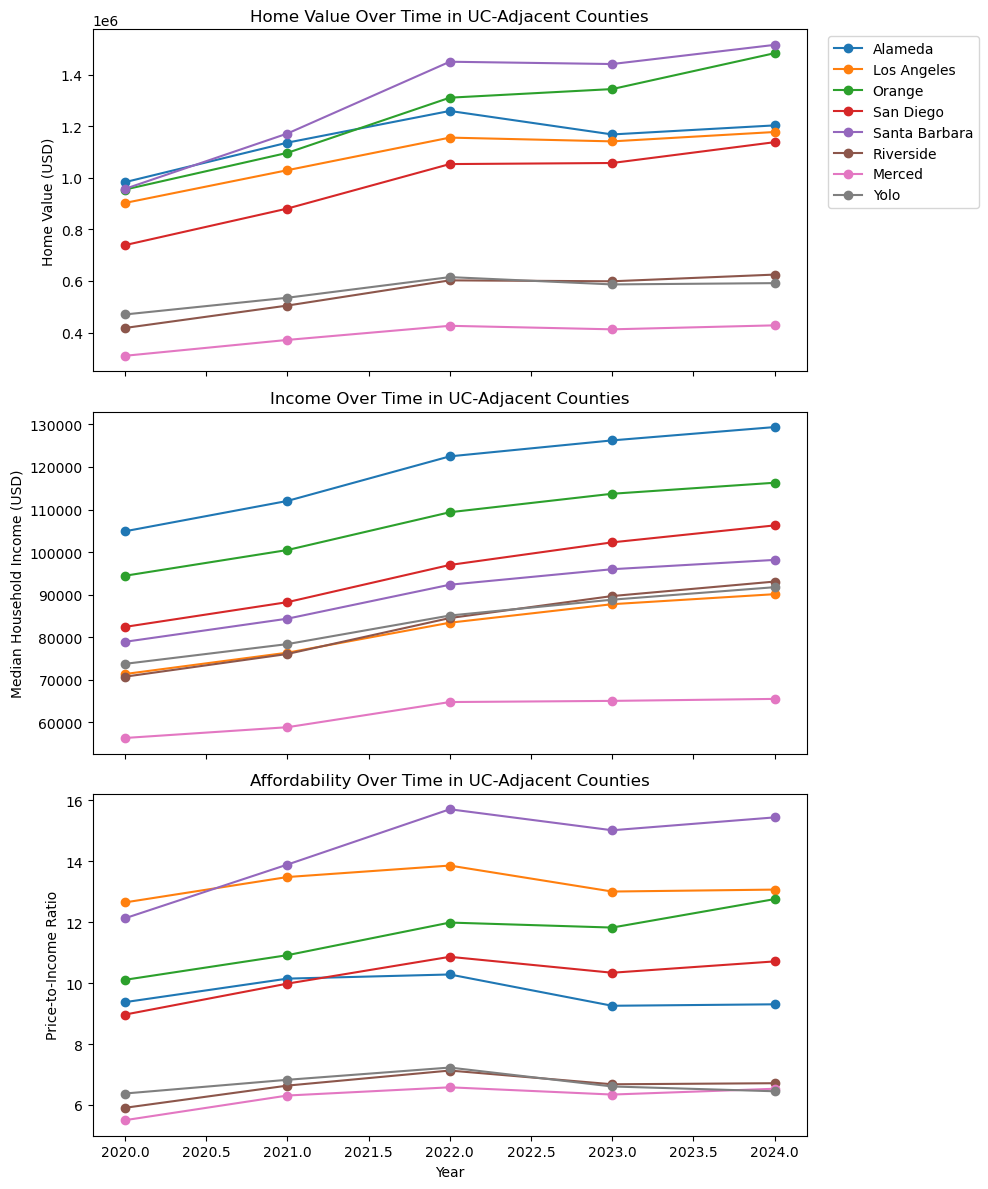

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for county in uc_counties:
    sub = uc_panel[uc_panel["county"] == county]
    axes[0].plot(sub["year"], sub["home_value"], marker="o", label=county)
    axes[1].plot(sub["year"], sub["median_household_income"], marker="o", label=county)
    axes[2].plot(sub["year"], sub["price_to_income"], marker="o", label=county)

axes[0].set_ylabel("Home Value (USD)")
axes[0].set_title("Home Value Over Time in UC-Adjacent Counties")

axes[1].set_ylabel("Median Household Income (USD)")
axes[1].set_title("Income Over Time in UC-Adjacent Counties")

axes[2].set_ylabel("Price-to-Income Ratio")
axes[2].set_xlabel("Year")
axes[2].set_title("Affordability Over Time in UC-Adjacent Counties")

axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation (time trends):**  
For most UC-adjacent counties, both average home values and median household income increase from 2020 to 2024, but home values are larger in magnitude and often rise more steeply in expensive coastal counties. The price-to-income ratio shows how affordability changes over time: counties such as Santa Barbara and Los Angeles remain at high ratios throughout the period, indicating persistently low affordability, while inland counties such as Merced and Riverside remain at lower ratios. These patterns suggest that affordability pressure is both higher and more persistent in coastal and metropolitan UC-adjacent counties.

#### Yearly Growth Rates: Home Value vs Income

To evaluate our first hypothesis more directly, we calculate yearly growth rates in home value and median household income for each UC-adjacent county. Comparing these growth rates helps us assess whether housing values are rising faster than income.

          county  year    home_value  median_household_income  \
0        Alameda  2020  9.833614e+05                   104888   
1        Alameda  2021  1.136718e+06                   112017   
2        Alameda  2022  1.259659e+06                   122488   
3        Alameda  2023  1.168478e+06                   126240   
4        Alameda  2024  1.203604e+06                   129367   
90   Los Angeles  2020  9.027612e+05                    71358   
91   Los Angeles  2021  1.029808e+06                    76367   
92   Los Angeles  2022  1.156209e+06                    83411   
93   Los Angeles  2023  1.141601e+06                    87760   
94   Los Angeles  2024  1.177969e+06                    90112   
115       Merced  2020  3.096868e+05                    56330   
116       Merced  2021  3.712679e+05                    58861   

     price_to_income  house_value_growth  income_growth  ratio_growth  
0           9.375347                 NaN            NaN           NaN  
1         

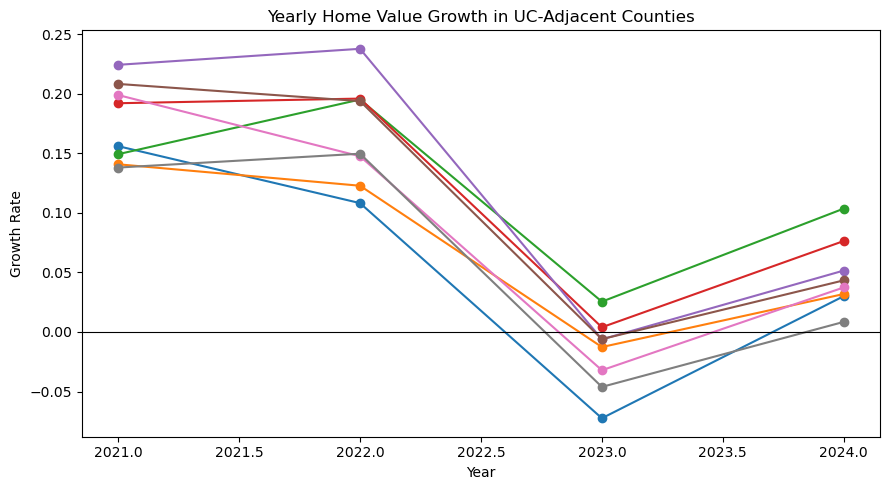

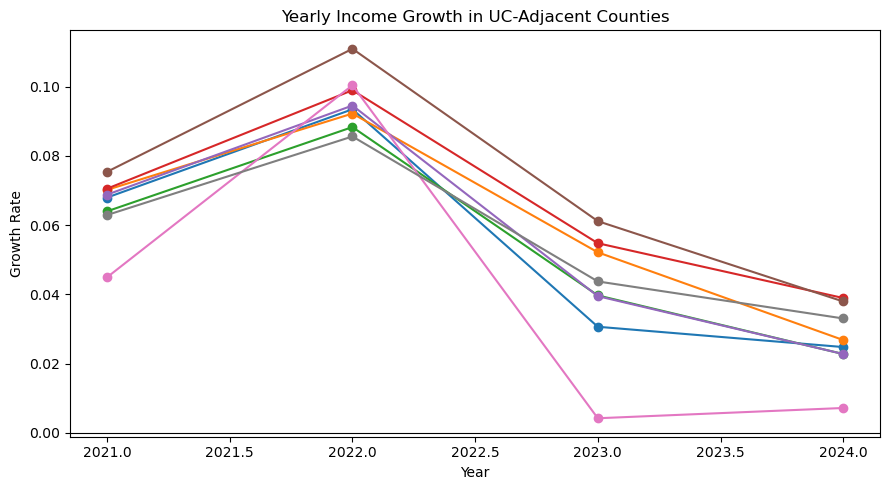

In [10]:
growth = uc_panel.sort_values(["county", "year"]).copy()

growth["house_value_growth"] = growth.groupby("county")["home_value"].pct_change()
growth["income_growth"] = growth.groupby("county")["median_household_income"].pct_change()
growth["ratio_growth"] = growth.groupby("county")["price_to_income"].pct_change()

print(growth.head(12))
plt.figure(figsize=(9, 5))
for county in uc_counties:
    sub = growth[growth["county"] == county]
    plt.plot(sub["year"], sub["house_value_growth"], marker="o", label=county)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Year")
plt.ylabel("Growth Rate")
plt.title("Yearly Home Value Growth in UC-Adjacent Counties")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
for county in uc_counties:
    sub = growth[growth["county"] == county]
    plt.plot(sub["year"], sub["income_growth"], marker="o", label=county)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Year")
plt.ylabel("Growth Rate")
plt.title("Yearly Income Growth in UC-Adjacent Counties")
plt.tight_layout()
plt.show()

**Interpretation (growth rates):**  
The growth-rate plots show how quickly home values and incomes changed from year to year in UC-adjacent counties. In several coastal and metropolitan counties, home value growth is positive in most years and sometimes exceeds income growth, which is consistent with worsening affordability. In other counties, income growth is more similar to home value growth, suggesting relatively more stable affordability. Together, the trend and growth-rate results show both the level of affordability and the pace at which affordability changed over time.

In [11]:
comparison = growth.dropna(subset=["house_value_growth", "income_growth"]).copy()
comparison["home_faster"] = comparison["house_value_growth"] > comparison["income_growth"]

summary_by_county = (
    comparison.groupby("county")
    .agg(mean_house_growth=("house_value_growth", "mean"),
         mean_income_growth=("income_growth", "mean"),
         years_home_faster=("home_faster", "sum"),
         comparison_years=("home_faster", "count"))
    .reset_index()
)

summary_by_county["avg_growth_gap"] = (
    summary_by_county["mean_house_growth"] - summary_by_county["mean_income_growth"]
)

summary_by_county = summary_by_county.sort_values("avg_growth_gap", ascending=False)
summary_by_county

,county,mean_house_growth,mean_income_growth,years_home_faster,comparison_years,avg_growth_gap
6,Santa Barbara,0.126815,0.056399,3,4,0.070415
3,Orange,0.118326,0.053694,3,4,0.064632
5,San Diego,0.117044,0.065806,3,4,0.051238
2,Merced,0.087906,0.039180,3,4,0.048726
4,Riverside,0.109825,0.071359,3,4,0.038465
1,Los Angeles,0.070674,0.060343,3,4,0.010331
7,Yolo,0.062503,0.056323,2,4,0.006180
0,Alameda,0.055445,0.054212,3,4,0.001234


### Results Summary

Our results show four main patterns. First, county home values vary much more than county income across California, indicating that housing costs differ more dramatically across counties than income does. Second, affordability differs substantially across UC-adjacent counties: coastal and metropolitan counties such as Santa Barbara and Los Angeles have much higher price-to-income ratios than inland counties such as Merced and Riverside. Third, county median household income and county average home value are strongly positively associated across California, but higher income does not necessarily imply better affordability. Instead, many high-income counties also have high housing costs. Finally, the county-year trend and growth-rate analyses suggest that home values often increased faster than income in several UC-adjacent counties from 2020 to 2024, which is consistent with worsening affordability over time.

## Ethics

We use only aggregated, publicly available data from Zillow and the U.S. Census American Community Survey. There are no individual-level records or identifying details in the datasets we analyze. Because of this, the privacy risk in our project is low.

Even so, we considered possible sources of bias and uncertainty. Zillow Home Value Index values are estimates rather than exact transaction prices, and ACS income figures are survey-based estimates that include sampling error. To address these concerns, we are transparent about the limitations of the data, avoid making claims about individuals, and interpret our findings as descriptive patterns about counties and regions rather than causal conclusions about specific populations. Our discussion of affordability focuses on structural trends, such as housing supply, demand, and regional inequality, rather than blaming particular groups of residents.

## Discussion and Conclusion
We examined housing affordability in regions surrounding UC campuses using Zillow Home Value Index data and ACS median household income for 2020–2024. Across eight UC-adjacent counties, we found large differences in price-to-income ratios: Santa Barbara and Los Angeles had the highest ratios (about 14.5 and 13.2), indicating that home values are many times median income, while Merced and Riverside had the lowest (about 6.3 and 6.6). At the county level across all of California, median household income and average home value were strongly positively correlated (Pearson r ≈ 0.91), so higher-income counties tend to have higher housing prices. Our findings align with prior evidence that coastal and urban California markets have seen strong price growth and that housing pressure near universities is a concern. The gap between home values and income in many UC-adjacent counties supports the view that affordability has worsened in these regions.

Overall, we learned that affordability varies substantially across UC regions: coastal and metro counties (e.g., Santa Barbara, Los Angeles, Orange) consistently show much worse affordability than inland counties (e.g., Merced, Riverside, Yolo). The strong income–price correlation at the county level further suggests that higher incomes are closely matched with higher housing costs in the same areas, rather than income alone explaining affordability. The impact of this project on society is that housing affordability near UC campuses is a real issue that affects students and families. As housing prices rise faster than income, it becomes much more difficult to afford living near campus, creating financial pressure and highlighting that some regions are much less affordable than others, which leads to inequality.

There are several limitations to this project. Our analysis is primarily descriptive rather than causal, and although we examine county-year trends and yearly growth rates, we do not use more advanced longitudinal modeling. ZHVI covers single-family homes only, so renters and other housing types are not directly captured. Income data are ACS estimates and are subject to sampling error. In addition, county-level averages do not capture within-county neighborhood differences. We also do not control for other factors, such as housing supply, interest rates, or demographics, which may influence affordability. Future work could include rental data, finer geographic units such as ZIP codes or census tracts, and additional modeling to better understand the drivers of housing affordability near UC campuses.